In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch
import gc

# 1. Manually trigger garbage collection to free CPU memory
gc.collect()

# 2. Clear PyTorch's cached memory from the GPU
torch.cuda.empty_cache()

# 3. Print the current GPU usage to verify the reset
print(f"Current GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
print(f"Current GPU Memory Cached: {torch.cuda.memory_reserved(0) / 1024**2:.2f} MB")

Current GPU Memory Allocated: 0.00 MB
Current GPU Memory Cached: 0.00 MB


In [2]:
# =====================================================
# NIH ChestXray14 - DATA PREPARATION
# =====================================================

import os
import torch
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image as PILImage

# =====================================================
# DEVICE CONFIGURATION
# =====================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

# =====================================================
# LABELS
# =====================================================

ALL_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia"
]

# =====================================================
# LOCATE DATASET
# =====================================================

print("Searching for NIH ChestXray14 dataset...")

df = None

for root, _, files in os.walk("/kaggle/input"):

    if "Data_Entry_2017.csv" in files:

        csv_path = os.path.join(
            root,
            "Data_Entry_2017.csv"
        )

        df = pd.read_csv(csv_path)

        IMG_DIR = root

        print(f"Dataset found at: {root}")

        break

if df is None:
    raise FileNotFoundError(
        "Data_Entry_2017.csv not found."
    )

# =====================================================
# Limiting the dataset to run faster.
# =====================================================

df = (
    df.sample(
        n=10000,
        random_state=42
    )
    .reset_index(drop=True)
)

print(f"Working dataset size: {len(df)}")

# =====================================================
# CLEAN LABELS
# =====================================================

df["Finding Labels"] = df["Finding Labels"].apply(
    lambda x:
    x.replace("|No Finding", "")
     .replace("No Finding|", "")
     .replace("No Finding", "")
)

# =====================================================
# CREATE MULTI-LABEL TARGETS
# =====================================================

for label in ALL_LABELS:

    df[label] = df["Finding Labels"].apply(
        lambda x:
        1.0 if label in str(x).split("|")
        else 0.0
    )

# =====================================================
# PATIENT-WISE SPLIT
# =====================================================

print("\nCreating patient-wise split...")

unique_patients = df["Patient ID"].unique()

np.random.seed(42)
np.random.shuffle(unique_patients)

train_size = int(
    0.80 * len(unique_patients)
)

train_patients = unique_patients[:train_size]
test_patients = unique_patients[train_size:]

train_df = (
    df[
        df["Patient ID"].isin(train_patients)
    ]
    .reset_index(drop=True)
)

test_df = (
    df[
        df["Patient ID"].isin(test_patients)
    ]
    .reset_index(drop=True)
)

# =====================================================
# VERIFY NO PATIENT LEAKAGE
# =====================================================

train_patient_ids = set(
    train_df["Patient ID"]
)

test_patient_ids = set(
    test_df["Patient ID"]
)

overlap = train_patient_ids.intersection(
    test_patient_ids
)

print("=" * 60)
print("PATIENT LEAKAGE VERIFICATION")
print("=" * 60)

print(
    f"Training Patients : {len(train_patient_ids)}"
)

print(
    f"Testing Patients  : {len(test_patient_ids)}"
)

print(
    f"Overlapping Patients : {len(overlap)}"
)

assert len(overlap) == 0, \
    "Patient leakage detected!"

print(
    "✓ Leakage-safe patient-wise split confirmed."
)

# =====================================================
# BUILD IMAGE PATH MAP
# =====================================================

print("\nBuilding image path map...")

img_map = {

    file_name:
    os.path.join(root, file_name)

    for root, _, files in os.walk(IMG_DIR)

    for file_name in files

    if file_name.endswith(".png")
}

print(
    f"Mapped {len(img_map)} images."
)

# =====================================================
# DATASET CLASS
# =====================================================

class MedicalDataset(Dataset):

    def __init__(
        self,
        dataframe,
        img_map,
        transform=None
    ):

        self.df = dataframe
        self.img_map = img_map
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_name = self.df.loc[
            idx,
            "Image Index"
        ]

        if img_name not in self.img_map:
            raise FileNotFoundError(
                f"Image not found: {img_name}"
            )

        image = PILImage.open(
            self.img_map[img_name]
        ).convert("RGB")

        labels = torch.tensor(
            self.df.loc[
                idx,
                ALL_LABELS
            ].values.astype(np.float32)
        )

        if self.transform:
            image = self.transform(image)

        return image, labels

# =====================================================
# IMAGE TRANSFORMS
# =====================================================

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =====================================================
# DATASETS
# =====================================================

train_dataset = MedicalDataset(
    train_df,
    img_map,
    train_transform
)

test_dataset = MedicalDataset(
    test_df,
    img_map,
    test_transform
)

# =====================================================
# DATA LOADERS
# =====================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =====================================================
# PIPELINE VERIFICATION
# =====================================================

print("\nVerifying data pipeline...")

for images, labels in train_loader:

    print(
        f"Batch Image Shape : {images.shape}"
    )

    print(
        f"Batch Label Shape : {labels.shape}"
    )

    break

print(
    "✓ Verification successful."
)

# =====================================================
# FINAL SUMMARY
# =====================================================

print("\nData Preparation Complete")

print(
    f"Train Samples : {len(train_df)}"
)

print(
    f"Test Samples  : {len(test_df)}"
)

print(
    f"Train Patients: {len(train_patient_ids)}"
)

print(
    f"Test Patients : {len(test_patient_ids)}"
)

Using device: cuda
Searching for NIH ChestXray14 dataset...
Dataset found at: /kaggle/input/datasets/organizations/nih-chest-xrays/data
Working dataset size: 10000

Creating patient-wise split...
PATIENT LEAKAGE VERIFICATION
Training Patients : 5319
Testing Patients  : 1330
Overlapping Patients : 0
✓ Leakage-safe patient-wise split confirmed.

Building image path map...
Mapped 112120 images.

Verifying data pipeline...
Batch Image Shape : torch.Size([64, 3, 224, 224])
Batch Label Shape : torch.Size([64, 14])
✓ Verification successful.

Data Preparation Complete
Train Samples : 8008
Test Samples  : 1992
Train Patients: 5319
Test Patients : 1330


In [3]:
import torch
import torch.nn as nn

# =====================================================
# CUSTOM CNN FOR CHEST X-RAY14
# =====================================================

class CustomCNN(nn.Module):

    def __init__(self, num_classes=14):

        super(CustomCNN, self).__init__()

        # ---------------------------------------------
        # Feature Extraction Layers
        # ---------------------------------------------
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # ---------------------------------------------
        # Classifier
        # Input:
        # 224 × 224
        #
        # After Pool 1:
        # 112 × 112
        #
        # After Pool 2:
        # 56 × 56
        #
        # Feature Size:
        # 64 × 56 × 56
        # ---------------------------------------------
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 56 * 56,
                128
            ),

            nn.ReLU(inplace=False),

            nn.Dropout(
                p=0.5
            ),

            nn.Linear(
                128,
                num_classes
            )
        )

    # -------------------------------------------------
    # Forward Pass
    # -------------------------------------------------
    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# =====================================================
# MODEL CHECK
# =====================================================

model = CustomCNN(num_classes=14)

print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=14, bias=True)
  )
)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# MODEL SETUP
# =====================================================
model = CustomCNN().to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.1
)

# =====================================================
# CLASS WEIGHTS
# =====================================================
total_samples = len(train_loader.dataset)

pos_counts = torch.zeros(14)

for _, labels in train_loader:
    pos_counts += labels.sum(dim=0)

pos_weights = (
    total_samples - pos_counts
) / (
    pos_counts + 1e-6
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weights.to(device)
)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader):

    model.eval()

    total_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            loss = criterion(outputs, targets)

            total_loss += loss.item()

            probs = torch.sigmoid(outputs)

            all_preds.append(probs.cpu())
            all_targets.append(targets.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    preds = (all_preds > 0.5).float()

    accuracy = (
        (preds == all_targets)
        .float()
        .mean()
        * 100
    )

    avg_loss = total_loss / len(loader)

    return avg_loss, accuracy.item()

# =====================================================
# HISTORY TRACKING
# =====================================================
train_losses = []
test_losses = []
test_accuracies = []

best_test_acc = 0.0

# =====================================================
# TRAINING LOOP
# =====================================================
for epoch in range(1, 11):

    model.train()

    total_train_loss = 0

    for images, targets in train_loader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    # -------------------------
    # Average Training Loss
    # -------------------------
    avg_train_loss = (
        total_train_loss /
        len(train_loader)
    )

    train_losses.append(avg_train_loss)

    # -------------------------
    # Validation/Test
    # -------------------------
    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    scheduler.step(test_loss)

    # -------------------------
    # Save Best Model
    # -------------------------
    if test_acc > best_test_acc:

        best_test_acc = test_acc

        torch.save(
            model.state_dict(),
            "customcnn_best_model.pth"
        )

        print(
            f"Epoch {epoch}: "
            f"New best CustomCNN model saved "
            f"with Acc: {test_acc:.2f}%"
        )

    print(
        f"Epoch [{epoch}/10] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

    print("-" * 60)

# =====================================================
# SAVE TRAINING HISTORY
# =====================================================
customcnn_history = {
    "train_loss": train_losses,
    "test_loss": test_losses,
    "test_accuracy": test_accuracies
}

torch.save(
    customcnn_history,
    "customcnn_history.pth"
)

# =====================================================
# FINAL SUMMARY
# =====================================================
print("\nTraining Complete.")

print(
    f"Best Test Accuracy: "
    f"{best_test_acc:.2f}%"
)

print(
    "Best model saved as: "
    "'customcnn_best_model.pth'"
)

print(
    "Training history saved as: "
    "'customcnn_history.pth'"
)

Epoch 1: New best CustomCNN model saved with Acc: 61.78%
Epoch [1/10] | Train Loss: 1.3270 | Test Loss: 1.2358 | Test Acc: 61.78%
------------------------------------------------------------
Epoch [2/10] | Train Loss: 1.3154 | Test Loss: 1.2370 | Test Acc: 40.68%
------------------------------------------------------------
Epoch [3/10] | Train Loss: 1.3032 | Test Loss: 1.2177 | Test Acc: 54.01%
------------------------------------------------------------
Epoch [4/10] | Train Loss: 1.2986 | Test Loss: 1.2031 | Test Acc: 53.80%
------------------------------------------------------------
Epoch [5/10] | Train Loss: 1.2838 | Test Loss: 1.2099 | Test Acc: 40.47%
------------------------------------------------------------
Epoch [6/10] | Train Loss: 1.2898 | Test Loss: 1.2015 | Test Acc: 60.80%
------------------------------------------------------------
Epoch [7/10] | Train Loss: 1.2768 | Test Loss: 1.2083 | Test Acc: 49.28%
------------------------------------------------------------
Epoch

In [5]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve
)

import numpy as np
import torch
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# -----------------------------
# Suppress warnings
# -----------------------------
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Evaluating CustomCNN model...")

# -----------------------------
# Load Best Model
# -----------------------------
model = CustomCNN().to(device)
model.load_state_dict(torch.load('customcnn_best_model.pth'))
model.eval()

# -----------------------------
# Get Predictions
# -----------------------------
all_probs = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:

        images = images.to(device)

        outputs = torch.sigmoid(model(images))

        all_probs.append(outputs.cpu().numpy())
        all_targets.append(targets.numpy())

y_probs = np.vstack(all_probs)
y_true = np.vstack(all_targets)

# =====================================================
# AUROC
# =====================================================
auroc_scores = []

for i in range(y_true.shape[1]):

    try:
        score = roc_auc_score(
            y_true[:, i],
            y_probs[:, i]
        )

    except ValueError:
        score = np.nan

    auroc_scores.append(score)

mean_auroc = np.nanmean(auroc_scores)

# =====================================================
# PR-AUC
# =====================================================
pr_auc_scores = []

for i in range(y_true.shape[1]):

    try:
        score = average_precision_score(
            y_true[:, i],
            y_probs[:, i]
        )

    except ValueError:
        score = np.nan

    pr_auc_scores.append(score)

mean_pr_auc = np.nanmean(pr_auc_scores)

# =====================================================
# Threshold Optimization
# =====================================================
best_thresholds = []

for i in range(y_true.shape[1]):

    if np.sum(y_true[:, i]) > 0:

        precision, recall, thresholds = precision_recall_curve(
            y_true[:, i],
            y_probs[:, i]
        )

        f1_scores = (
            2 * precision * recall
        ) / (
            precision + recall + 1e-10
        )

        if len(thresholds) > 0:

            best_idx = np.argmax(f1_scores[:-1])

            best_thresholds.append(
                thresholds[best_idx]
            )

        else:

            best_thresholds.append(0.5)

    else:

        best_thresholds.append(0.5)

best_thresholds = np.array(best_thresholds)

# =====================================================
# Final Predictions
# =====================================================
y_pred = (
    y_probs > best_thresholds
).astype(int)

# =====================================================
# Macro Metrics
# =====================================================
macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

# =====================================================
# Micro Metrics
# =====================================================
micro_f1 = f1_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

micro_precision = precision_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

micro_recall = recall_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

# =====================================================
# Summary Results
# =====================================================
print("\n" + "=" * 60)
print("OVERALL PERFORMANCE")
print("=" * 60)

print(f"Mean AUROC      : {mean_auroc:.4f}")
print(f"Mean PR-AUC     : {mean_pr_auc:.4f}")

print(f"Macro F1        : {macro_f1:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")

print(f"Micro F1        : {micro_f1:.4f}")
print(f"Micro Precision : {micro_precision:.4f}")
print(f"Micro Recall    : {micro_recall:.4f}")

# =====================================================
# Per Label AUROC
# =====================================================
print("\n")
print("=" * 60)
print("PER-LABEL AUROC")
print("=" * 60)

for i, label in enumerate(ALL_LABELS):

    print(
        f"{label:<20} : "
        f"{auroc_scores[i]:.4f}"
    )

# =====================================================
# Per Label PR-AUC
# =====================================================
print("\n")
print("=" * 60)
print("PER-LABEL PR-AUC")
print("=" * 60)

for i, label in enumerate(ALL_LABELS):

    print(
        f"{label:<20} : "
        f"{pr_auc_scores[i]:.4f}"
    )

print("\nEvaluation Complete.")

customcnn_results = {
    "Model": "CustomCNN",
    "Mean AUROC": mean_auroc,
    "Mean PR-AUC": mean_pr_auc,
    "Macro F1": macro_f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Micro F1": micro_f1,
    "Micro Precision": micro_precision,
    "Micro Recall": micro_recall
}

Evaluating CustomCNN model...

OVERALL PERFORMANCE
Mean AUROC      : 0.5930
Mean PR-AUC     : 0.0728
Macro F1        : 0.1170
Macro Precision : 0.0831
Macro Recall    : 0.3719
Micro F1        : 0.1601
Micro Precision : 0.0943
Micro Recall    : 0.5276


PER-LABEL AUROC
Atelectasis          : 0.6193
Cardiomegaly         : 0.7016
Effusion             : 0.6807
Infiltration         : 0.5901
Mass                 : 0.5013
Nodule               : 0.4681
Pneumonia            : 0.6715
Pneumothorax         : 0.5432
Consolidation        : 0.6871
Edema                : 0.6943
Emphysema            : 0.5479
Fibrosis             : 0.5504
Pleural_Thickening   : 0.4532
Hernia               : nan


PER-LABEL PR-AUC
Atelectasis          : 0.1413
Cardiomegaly         : 0.0472
Effusion             : 0.2316
Infiltration         : 0.2363
Mass                 : 0.0502
Nodule               : 0.0388
Pneumonia            : 0.0246
Pneumothorax         : 0.0607
Consolidation        : 0.0617
Edema                : 0.

In [6]:
from torchvision import models
import torch
import torch.nn as nn

# =====================================================
# RESNET18 TRANSFER LEARNING MODEL
# NIH CHEST X-RAY14 (14 LABELS)
# =====================================================

class ResNet18Custom(nn.Module):

    def __init__(self, num_classes=14):

        super().__init__()

        # ---------------------------------------------
        # Load Pretrained ResNet18
        # ---------------------------------------------
        self.model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # ---------------------------------------------
        # Replace Final Classification Layer
        # Original:
        # 512 -> 1000
        #
        # New:
        # 512 -> 14
        # ---------------------------------------------
        num_features = self.model.fc.in_features

        self.model.fc = nn.Linear(
            num_features,
            num_classes
        )

    # ---------------------------------------------
    # Forward Pass
    # ---------------------------------------------
    def forward(self, x):

        return self.model(x)


# =====================================================
# MODEL INITIALIZATION
# =====================================================

model = ResNet18Custom(
    num_classes=14
).to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


ResNet18Custom(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# MODEL SETUP
# =====================================================
model = ResNet18Custom().to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.1
)

# =====================================================
# CLASS WEIGHTS
# =====================================================
total_samples = len(train_loader.dataset)

pos_counts = torch.zeros(14)

for _, labels in train_loader:
    pos_counts += labels.sum(dim=0)

pos_weights = (
    total_samples - pos_counts
) / (
    pos_counts + 1e-6
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weights.to(device)
)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader):

    model.eval()

    total_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            loss = criterion(outputs, targets)

            total_loss += loss.item()

            probs = torch.sigmoid(outputs)

            all_preds.append(probs.cpu())
            all_targets.append(targets.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    preds = (all_preds > 0.5).float()

    accuracy = (
        (preds == all_targets)
        .float()
        .mean()
        * 100
    )

    avg_loss = total_loss / len(loader)

    return avg_loss, accuracy.item()

# =====================================================
# HISTORY TRACKING
# =====================================================
train_losses = []
test_losses = []
test_accuracies = []

best_test_acc = 0.0

# =====================================================
# TRAINING LOOP
# =====================================================
for epoch in range(1, 11):

    model.train()

    total_train_loss = 0

    for images, targets in train_loader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    # -------------------------
    # Average Training Loss
    # -------------------------
    avg_train_loss = (
        total_train_loss /
        len(train_loader)
    )

    train_losses.append(avg_train_loss)

    # -------------------------
    # Validation/Test
    # -------------------------
    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    scheduler.step(test_loss)

    # -------------------------
    # Save Best Model
    # -------------------------
    if test_acc > best_test_acc:

        best_test_acc = test_acc

        torch.save(
            model.state_dict(),
            "resnet18_best_model.pth"
        )

        print(
            f"Epoch {epoch}: "
            f"New best ResNet18 model saved "
            f"with Acc: {test_acc:.2f}%"
        )

    print(
        f"Epoch [{epoch}/10] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

    print("-" * 60)

# =====================================================
# SAVE TRAINING HISTORY
# =====================================================
resnet_history = {
    "train_loss": train_losses,
    "test_loss": test_losses,
    "test_accuracy": test_accuracies
}

torch.save(
    resnet_history,
    "resnet18_history.pth"
)

# =====================================================
# FINAL SUMMARY
# =====================================================
print("\nTraining Complete.")

print(
    f"Best Test Accuracy: "
    f"{best_test_acc:.2f}%"
)

print(
    "Best model saved as: "
    "'resnet18_best_model.pth'"
)

print(
    "Training history saved as: "
    "'resnet18_history.pth'"
)

Epoch 1: New best ResNet18 model saved with Acc: 36.84%
Epoch [1/10] | Train Loss: 1.6103 | Test Loss: 1.9440 | Test Acc: 36.84%
------------------------------------------------------------
Epoch 2: New best ResNet18 model saved with Acc: 64.28%
Epoch [2/10] | Train Loss: 1.4696 | Test Loss: 1.2010 | Test Acc: 64.28%
------------------------------------------------------------
Epoch [3/10] | Train Loss: 1.3689 | Test Loss: 1.2108 | Test Acc: 50.34%
------------------------------------------------------------
Epoch [4/10] | Train Loss: 1.3262 | Test Loss: 1.3472 | Test Acc: 42.42%
------------------------------------------------------------
Epoch 5: New best ResNet18 model saved with Acc: 64.63%
Epoch [5/10] | Train Loss: 1.3822 | Test Loss: 1.4603 | Test Acc: 64.63%
------------------------------------------------------------
Epoch [6/10] | Train Loss: 1.2440 | Test Loss: 1.2712 | Test Acc: 60.49%
------------------------------------------------------------
Epoch [7/10] | Train Loss: 1

In [8]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve
)

import numpy as np
import torch
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# =====================================================
# Suppress Warnings
# =====================================================
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Evaluating ResNet18 model...")

# =====================================================
# Load Best Model
# =====================================================
model = ResNet18Custom().to(device)
model.load_state_dict(torch.load('resnet18_best_model.pth'))
model.eval()

# =====================================================
# Get Predictions
# =====================================================
all_probs = []
all_targets = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)

        outputs = torch.sigmoid(model(images))

        all_probs.append(outputs.cpu().numpy())
        all_targets.append(targets.numpy())

y_probs = np.vstack(all_probs)
y_true = np.vstack(all_targets)

# =====================================================
# AUROC
# =====================================================
auroc_scores = []

for i in range(y_true.shape[1]):

    try:
        score = roc_auc_score(
            y_true[:, i],
            y_probs[:, i]
        )

    except ValueError:
        score = np.nan

    auroc_scores.append(score)

mean_auroc = np.nanmean(auroc_scores)

# =====================================================
# PR-AUC
# =====================================================
pr_auc_scores = []

for i in range(y_true.shape[1]):

    try:
        score = average_precision_score(
            y_true[:, i],
            y_probs[:, i]
        )

    except ValueError:
        score = np.nan

    pr_auc_scores.append(score)

mean_pr_auc = np.nanmean(pr_auc_scores)

# =====================================================
# Threshold Optimization
# =====================================================
best_thresholds = []

for i in range(y_true.shape[1]):

    if np.sum(y_true[:, i]) > 0:

        precision, recall, thresholds = precision_recall_curve(
            y_true[:, i],
            y_probs[:, i]
        )

        f1_scores = (
            2 * precision * recall
        ) / (
            precision + recall + 1e-10
        )

        if len(thresholds) > 0:

            best_idx = np.argmax(f1_scores[:-1])

            best_thresholds.append(
                thresholds[best_idx]
            )

        else:

            best_thresholds.append(0.5)

    else:

        best_thresholds.append(0.5)

best_thresholds = np.array(best_thresholds)

# =====================================================
# Final Predictions
# =====================================================
y_pred = (
    y_probs > best_thresholds
).astype(int)

# =====================================================
# Macro Metrics
# =====================================================
macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

# =====================================================
# Micro Metrics
# =====================================================
micro_f1 = f1_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

micro_precision = precision_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

micro_recall = recall_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

# =====================================================
# OVERALL RESULTS
# =====================================================
print("\n" + "=" * 60)
print("OVERALL PERFORMANCE")
print("=" * 60)

print(f"Mean AUROC      : {mean_auroc:.4f}")
print(f"Mean PR-AUC     : {mean_pr_auc:.4f}")

print(f"Macro F1        : {macro_f1:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")

print(f"Micro F1        : {micro_f1:.4f}")
print(f"Micro Precision : {micro_precision:.4f}")
print(f"Micro Recall    : {micro_recall:.4f}")

# =====================================================
# PER-LABEL AUROC
# =====================================================
print("\n")
print("=" * 60)
print("PER-LABEL AUROC")
print("=" * 60)

for i, label in enumerate(ALL_LABELS):

    print(
        f"{label:<20} : "
        f"{auroc_scores[i]:.4f}"
    )

# =====================================================
# PER-LABEL PR-AUC
# =====================================================
print("\n")
print("=" * 60)
print("PER-LABEL PR-AUC")
print("=" * 60)

for i, label in enumerate(ALL_LABELS):

    print(
        f"{label:<20} : "
        f"{pr_auc_scores[i]:.4f}"
    )

print("\nResNet18 Evaluation Complete.")

resnet_results = {
    "Model": "ResNet18",
    "Mean AUROC": mean_auroc,
    "Mean PR-AUC": mean_pr_auc,
    "Macro F1": macro_f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Micro F1": micro_f1,
    "Micro Precision": micro_precision,
    "Micro Recall": micro_recall
}

Evaluating ResNet18 model...

OVERALL PERFORMANCE
Mean AUROC      : 0.6690
Mean PR-AUC     : 0.0922
Macro F1        : 0.1483
Macro Precision : 0.1113
Macro Recall    : 0.3080
Micro F1        : 0.1731
Micro Precision : 0.1100
Micro Recall    : 0.4062


PER-LABEL AUROC
Atelectasis          : 0.6926
Cardiomegaly         : 0.6915
Effusion             : 0.7205
Infiltration         : 0.6423
Mass                 : 0.5938
Nodule               : 0.4993
Pneumonia            : 0.6503
Pneumothorax         : 0.6404
Consolidation        : 0.6503
Edema                : 0.7892
Emphysema            : 0.6831
Fibrosis             : 0.7445
Pleural_Thickening   : 0.6988
Hernia               : nan


PER-LABEL PR-AUC
Atelectasis          : 0.1767
Cardiomegaly         : 0.0839
Effusion             : 0.2576
Infiltration         : 0.2958
Mass                 : 0.0715
Nodule               : 0.0385
Pneumonia            : 0.0203
Pneumothorax         : 0.0812
Consolidation        : 0.0593
Edema                : 0.0

In [9]:
from torchvision import models
import torch.nn as nn

# =====================================================
# VGG19 TRANSFER LEARNING MODEL
# NIH CHEST X-RAY14
# =====================================================

class VGG19Custom(nn.Module):

    def __init__(self, num_classes=14):

        super().__init__()

        # ---------------------------------------------
        # Load Pretrained VGG19
        # ---------------------------------------------
        vgg = models.vgg19(
            weights=models.VGG19_Weights.DEFAULT
        )

        # ---------------------------------------------
        # Feature Extractor
        # ---------------------------------------------
        self.features = vgg.features

        # ---------------------------------------------
        # Adaptive Average Pooling
        # Output: 512 x 7 x 7
        # ---------------------------------------------
        self.avgpool = vgg.avgpool

        # ---------------------------------------------
        # Custom Classifier
        # ---------------------------------------------
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                512 * 7 * 7,
                4096
            ),

            nn.ReLU(inplace=False),

            nn.Dropout(0.5),

            nn.Linear(
                4096,
                num_classes
            )
        )

    # ---------------------------------------------
    # Forward Pass
    # ---------------------------------------------
    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x


# =====================================================
# MODEL INITIALIZATION
# =====================================================

model = VGG19Custom(
    num_classes=14
).to(device)

print(model)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 194MB/s] 


VGG19Custom(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# MODEL SETUP
# =====================================================
model = VGG19Custom().to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.1
)

# =====================================================
# CLASS WEIGHTS
# =====================================================
total_samples = len(train_loader.dataset)

pos_counts = torch.zeros(14)

for _, labels in train_loader:
    pos_counts += labels.sum(dim=0)

pos_weights = (
    total_samples - pos_counts
) / (
    pos_counts + 1e-6
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weights.to(device)
)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader):

    model.eval()

    total_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            loss = criterion(outputs, targets)

            total_loss += loss.item()

            probs = torch.sigmoid(outputs)

            all_preds.append(probs.cpu())
            all_targets.append(targets.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    preds = (all_preds > 0.5).float()

    accuracy = (
        (preds == all_targets)
        .float()
        .mean()
        * 100
    )

    avg_loss = total_loss / len(loader)

    return avg_loss, accuracy.item()

# =====================================================
# HISTORY TRACKING
# =====================================================
train_losses = []
test_losses = []
test_accuracies = []

best_test_acc = 0.0

# =====================================================
# TRAINING LOOP
# =====================================================
for epoch in range(1, 11):

    model.train()

    total_train_loss = 0

    for images, targets in train_loader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    # -------------------------
    # Average Training Loss
    # -------------------------
    avg_train_loss = (
        total_train_loss /
        len(train_loader)
    )

    train_losses.append(avg_train_loss)

    # -------------------------
    # Validation/Test
    # -------------------------
    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    scheduler.step(test_loss)

    # -------------------------
    # Save Best Model
    # -------------------------
    if test_acc > best_test_acc:

        best_test_acc = test_acc

        torch.save(
            model.state_dict(),
            "vgg19_best_model.pth"
        )

        print(
            f"Epoch {epoch}: "
            f"New best model saved "
            f"with Acc: {test_acc:.2f}%"
        )

    print(
        f"Epoch [{epoch}/10] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

    print("-" * 60)

# =====================================================
# SAVE TRAINING HISTORY
# =====================================================
vgg_history = {
    "train_loss": train_losses,
    "test_loss": test_losses,
    "test_accuracy": test_accuracies
}

torch.save(
    vgg_history,
    "vgg19_history.pth"
)

# =====================================================
# FINAL SUMMARY
# =====================================================
print("\nTraining Complete.")

print(
    f"Best Test Accuracy: "
    f"{best_test_acc:.2f}%"
)

print(
    "Best model saved as: "
    "'vgg19_best_model.pth'"
)

print(
    "Training history saved as: "
    "'vgg19_history.pth'"
)

Epoch 1: New best model saved with Acc: 62.97%
Epoch [1/10] | Train Loss: 1.3552 | Test Loss: 1.2397 | Test Acc: 62.97%
------------------------------------------------------------
Epoch [2/10] | Train Loss: 1.3172 | Test Loss: 1.2384 | Test Acc: 45.05%
------------------------------------------------------------
Epoch [3/10] | Train Loss: 1.3148 | Test Loss: 1.2328 | Test Acc: 45.55%
------------------------------------------------------------
Epoch [4/10] | Train Loss: 1.3097 | Test Loss: 1.2219 | Test Acc: 30.79%
------------------------------------------------------------
Epoch [5/10] | Train Loss: 1.3152 | Test Loss: 1.2337 | Test Acc: 52.40%
------------------------------------------------------------
Epoch [6/10] | Train Loss: 1.2958 | Test Loss: 1.2193 | Test Acc: 60.21%
------------------------------------------------------------
Epoch 7: New best model saved with Acc: 81.56%
Epoch [7/10] | Train Loss: 1.3162 | Test Loss: 1.2423 | Test Acc: 81.56%
-----------------------------

In [11]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve
)

import numpy as np
import torch
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# =====================================================
# Suppress Warnings
# =====================================================
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Evaluating VGG19 model...")

# =====================================================
# Load Best Model
# =====================================================
model = VGG19Custom().to(device)
model.load_state_dict(torch.load('vgg19_best_model.pth'))
model.eval()

# =====================================================
# Get Predictions
# =====================================================
all_probs = []
all_targets = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)

        outputs = torch.sigmoid(model(images))

        all_probs.append(outputs.cpu().numpy())
        all_targets.append(targets.numpy())

y_probs = np.vstack(all_probs)
y_true = np.vstack(all_targets)

# =====================================================
# AUROC
# =====================================================
auroc_scores = []

for i in range(y_true.shape[1]):

    try:
        score = roc_auc_score(
            y_true[:, i],
            y_probs[:, i]
        )

    except ValueError:
        score = np.nan

    auroc_scores.append(score)

mean_auroc = np.nanmean(auroc_scores)

# =====================================================
# PR-AUC
# =====================================================
pr_auc_scores = []

for i in range(y_true.shape[1]):

    try:
        score = average_precision_score(
            y_true[:, i],
            y_probs[:, i]
        )

    except ValueError:
        score = np.nan

    pr_auc_scores.append(score)

mean_pr_auc = np.nanmean(pr_auc_scores)

# =====================================================
# Threshold Optimization
# =====================================================
best_thresholds = []

for i in range(y_true.shape[1]):

    if np.sum(y_true[:, i]) > 0:

        precision, recall, thresholds = precision_recall_curve(
            y_true[:, i],
            y_probs[:, i]
        )

        f1_scores = (
            2 * precision * recall
        ) / (
            precision + recall + 1e-10
        )

        if len(thresholds) > 0:

            best_idx = np.argmax(f1_scores[:-1])

            best_thresholds.append(
                thresholds[best_idx]
            )

        else:

            best_thresholds.append(0.5)

    else:

        best_thresholds.append(0.5)

best_thresholds = np.array(best_thresholds)

# =====================================================
# Final Predictions
# =====================================================
y_pred = (
    y_probs > best_thresholds
).astype(int)

# =====================================================
# Macro Metrics
# =====================================================
macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

# =====================================================
# Micro Metrics
# =====================================================
micro_f1 = f1_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

micro_precision = precision_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

micro_recall = recall_score(
    y_true,
    y_pred,
    average='micro',
    zero_division=0
)

# =====================================================
# OVERALL RESULTS
# =====================================================
print("\n" + "=" * 60)
print("OVERALL PERFORMANCE")
print("=" * 60)

print(f"Mean AUROC      : {mean_auroc:.4f}")
print(f"Mean PR-AUC     : {mean_pr_auc:.4f}")

print(f"Macro F1        : {macro_f1:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")

print(f"Micro F1        : {micro_f1:.4f}")
print(f"Micro Precision : {micro_precision:.4f}")
print(f"Micro Recall    : {micro_recall:.4f}")

# =====================================================
# PER-LABEL AUROC
# =====================================================
print("\n")
print("=" * 60)
print("PER-LABEL AUROC")
print("=" * 60)

for i, label in enumerate(ALL_LABELS):

    print(
        f"{label:<20} : "
        f"{auroc_scores[i]:.4f}"
    )

# =====================================================
# PER-LABEL PR-AUC
# =====================================================
print("\n")
print("=" * 60)
print("PER-LABEL PR-AUC")
print("=" * 60)

for i, label in enumerate(ALL_LABELS):

    print(
        f"{label:<20} : "
        f"{pr_auc_scores[i]:.4f}"
    )

print("\nVGG19 Evaluation Complete.")

vgg_results = {
    "Model": "VGG19",
    "Mean AUROC": mean_auroc,
    "Mean PR-AUC": mean_pr_auc,
    "Macro F1": macro_f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Micro F1": micro_f1,
    "Micro Precision": micro_precision,
    "Micro Recall": micro_recall
}

Evaluating VGG19 model...

OVERALL PERFORMANCE
Mean AUROC      : 0.5003
Mean PR-AUC     : 0.0501
Macro F1        : 0.0084
Macro Precision : 0.0524
Macro Recall    : 0.0728
Micro F1        : 0.0257
Micro Precision : 0.0215
Micro Recall    : 0.0320


PER-LABEL AUROC
Atelectasis          : 0.4986
Cardiomegaly         : 0.5008
Effusion             : 0.4980
Infiltration         : 0.5030
Mass                 : 0.4981
Nodule               : 0.4992
Pneumonia            : 0.4987
Pneumothorax         : 0.5008
Consolidation        : 0.5060
Edema                : 0.5087
Emphysema            : 0.4885
Fibrosis             : 0.5018
Pleural_Thickening   : 0.5013
Hernia               : nan


PER-LABEL PR-AUC
Atelectasis          : 0.0999
Cardiomegaly         : 0.0216
Effusion             : 0.1180
Infiltration         : 0.1831
Mass                 : 0.0507
Nodule               : 0.0397
Pneumonia            : 0.0131
Pneumothorax         : 0.0468
Consolidation        : 0.0357
Edema                : 0.0292

In [12]:
import zipfile
import os

files_to_zip = [
    "customcnn_best_model.pth",
    "resnet18_best_model.pth",
    "vgg19_best_model.pth",
    "customcnn_history.pth",
    "resnet18_history.pth",
    "vgg19_history.pth",
    "model_comparison_results.csv"
]

zip_path = "/kaggle/working/NIH_ChestXray_Project_Files.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for file in files_to_zip:
        full_path = f"/kaggle/working/{file}"
        if os.path.exists(full_path):
            zipf.write(full_path, arcname=file)

print("ZIP created:", zip_path)

ZIP created: /kaggle/working/NIH_ChestXray_Project_Files.zip


In [36]:
import os

for file in os.listdir("/kaggle/working"):
    print(file)

customcnn_history.pth
resnet18_history.pth
.virtual_documents
vgg19_history.pth
customcnn_best_model.pth
resnet18_best_model.pth
vgg19_best_model.pth
final_model_comparison.csv
NIH_ChestXray_Project_Files.zip


In [13]:
import pandas as pd

comparison_df = pd.DataFrame([
    customcnn_results,
    resnet_results,
    vgg_results
])

comparison_df = comparison_df.sort_values(
    by="Mean AUROC",
    ascending=False
)

comparison_df.reset_index(drop=True, inplace=True)

print(comparison_df)

comparison_df

       Model  Mean AUROC  Mean PR-AUC  Macro F1  Macro Precision  \
0   ResNet18    0.668978     0.092162  0.148331         0.111324   
1  CustomCNN    0.592982     0.072841  0.117044         0.083066   
2      VGG19    0.500272     0.050124  0.008433         0.052422   

   Macro Recall  Micro F1  Micro Precision  Micro Recall  
0      0.308024  0.173092         0.109974      0.406250  
1      0.371928  0.160053         0.094335      0.527616  
2      0.072783  0.025723         0.021516      0.031977  


,Model,Mean AUROC,Mean PR-AUC,Macro F1,Macro Precision,Macro Recall,Micro F1,Micro Precision,Micro Recall
0,ResNet18,0.668978,0.092162,0.148331,0.111324,0.308024,0.173092,0.109974,0.406250
1,CustomCNN,0.592982,0.072841,0.117044,0.083066,0.371928,0.160053,0.094335,0.527616
2,VGG19,0.500272,0.050124,0.008433,0.052422,0.072783,0.025723,0.021516,0.031977


In [14]:
best_model = comparison_df.iloc[0]

print("=" * 50)
print("BEST MODEL")
print("=" * 50)

print(f"Model      : {best_model['Model']}")
print(f"Mean AUROC : {best_model['Mean AUROC']:.4f}")
print(f"Mean PR-AUC: {best_model['Mean PR-AUC']:.4f}")
print(f"Macro F1   : {best_model['Macro F1']:.4f}")

BEST MODEL
Model      : ResNet18
Mean AUROC : 0.6690
Mean PR-AUC: 0.0922
Macro F1   : 0.1483


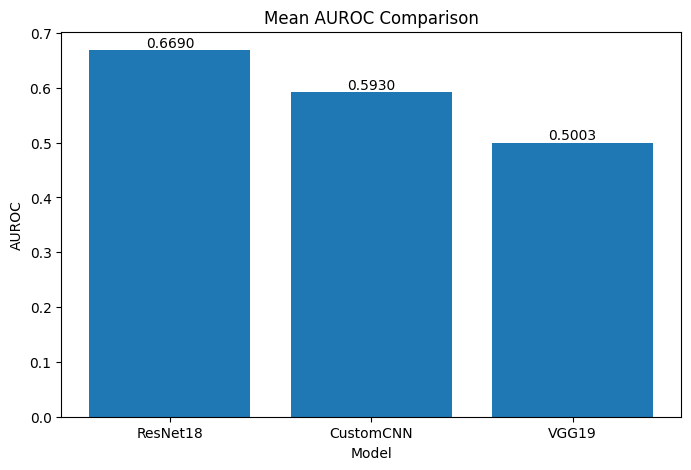

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Mean AUROC"]
)

plt.title("Mean AUROC Comparison")
plt.ylabel("AUROC")
plt.xlabel("Model")

for i, v in enumerate(comparison_df["Mean AUROC"]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')

plt.show()

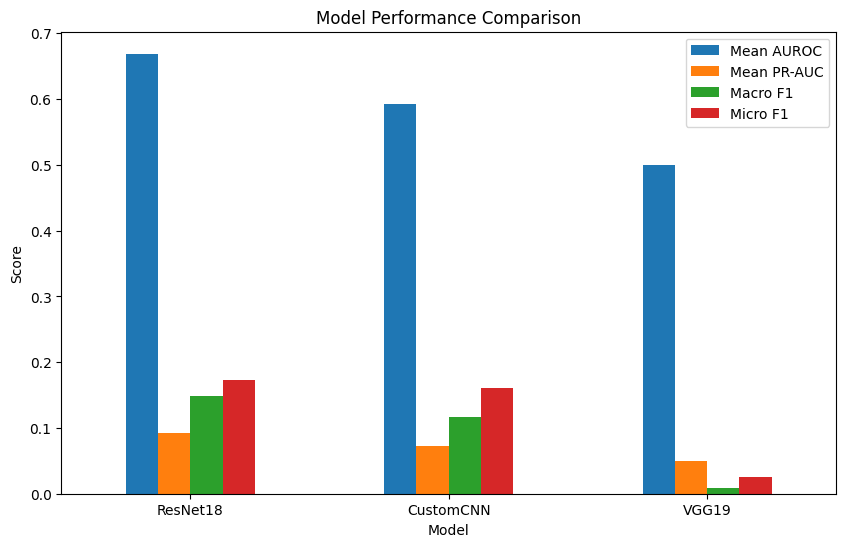

In [16]:
metrics = comparison_df.set_index("Model")[
    [
        "Mean AUROC",
        "Mean PR-AUC",
        "Macro F1",
        "Micro F1"
    ]
]

metrics.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

In [17]:
comparison_df.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Comparison results exported successfully.")

Comparison results exported successfully.


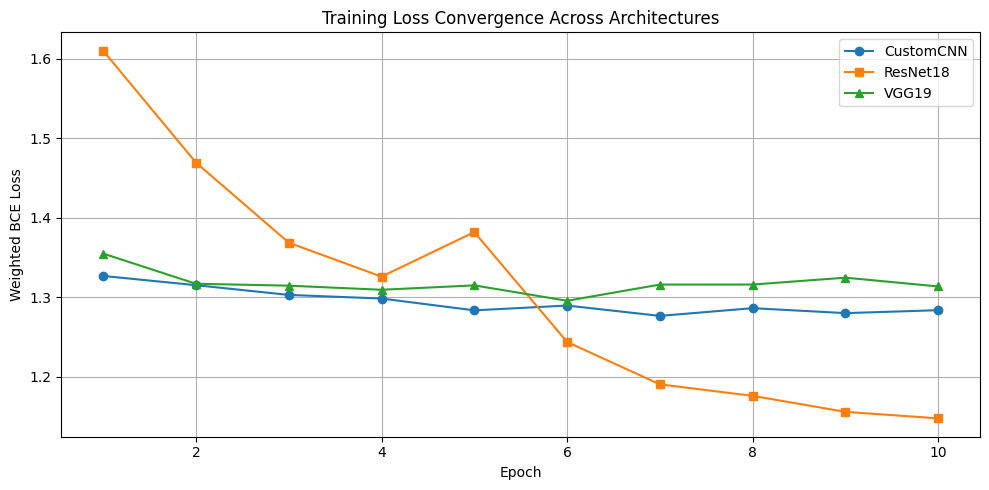

In [18]:
import torch
import matplotlib.pyplot as plt

# ==========================================
# Load Training Histories
# ==========================================
custom_history = torch.load("customcnn_history.pth")
resnet_history = torch.load("resnet18_history.pth")
vgg_history = torch.load("vgg19_history.pth")

# ==========================================
# Extract Training Losses
# ==========================================
custom_loss = custom_history["train_loss"]
resnet_loss = resnet_history["train_loss"]
vgg_loss = vgg_history["train_loss"]

# ==========================================
# Epoch Numbers
# ==========================================
epochs = range(
    1,
    len(custom_loss) + 1
)

# ==========================================
# Plot Training Loss Curves
# ==========================================
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    custom_loss,
    marker='o',
    label='CustomCNN'
)

plt.plot(
    epochs,
    resnet_loss,
    marker='s',
    label='ResNet18'
)

plt.plot(
    epochs,
    vgg_loss,
    marker='^',
    label='VGG19'
)

plt.title(
    "Training Loss Convergence Across Architectures"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted BCE Loss")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

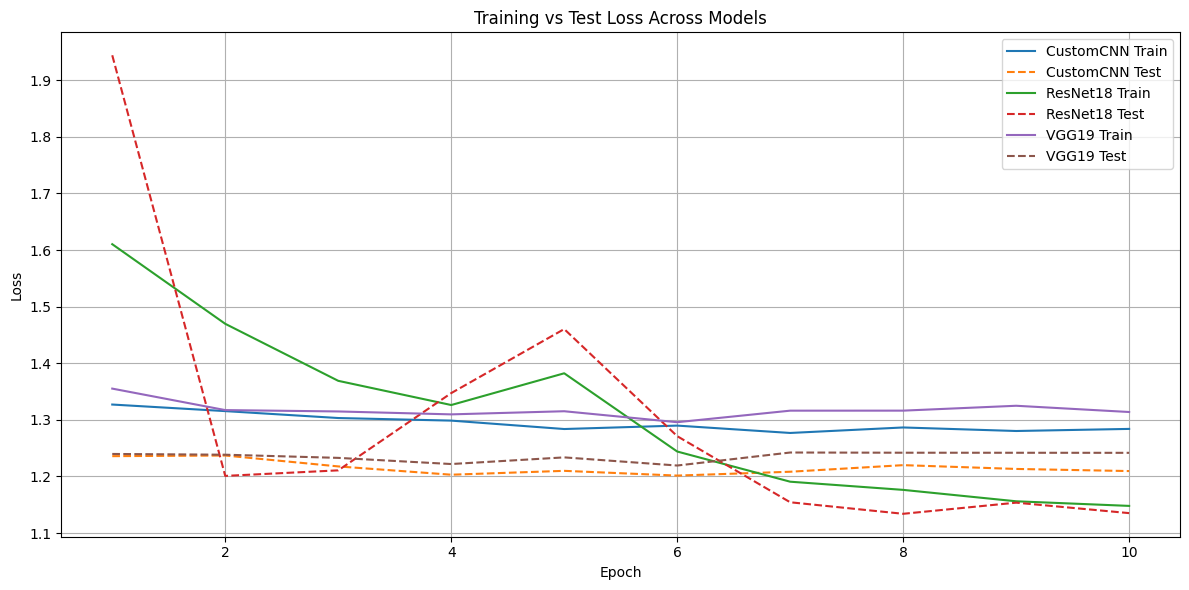

In [19]:
import torch
import matplotlib.pyplot as plt

custom_history = torch.load("customcnn_history.pth")
resnet_history = torch.load("resnet18_history.pth")
vgg_history = torch.load("vgg19_history.pth")

epochs = range(
    1,
    len(custom_history["train_loss"]) + 1
)

plt.figure(figsize=(12, 6))

plt.plot(
    epochs,
    custom_history["train_loss"],
    label="CustomCNN Train"
)

plt.plot(
    epochs,
    custom_history["test_loss"],
    linestyle="--",
    label="CustomCNN Test"
)

plt.plot(
    epochs,
    resnet_history["train_loss"],
    label="ResNet18 Train"
)

plt.plot(
    epochs,
    resnet_history["test_loss"],
    linestyle="--",
    label="ResNet18 Test"
)

plt.plot(
    epochs,
    vgg_history["train_loss"],
    label="VGG19 Train"
)

plt.plot(
    epochs,
    vgg_history["test_loss"],
    linestyle="--",
    label="VGG19 Test"
)

plt.title("Training vs Test Loss Across Models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

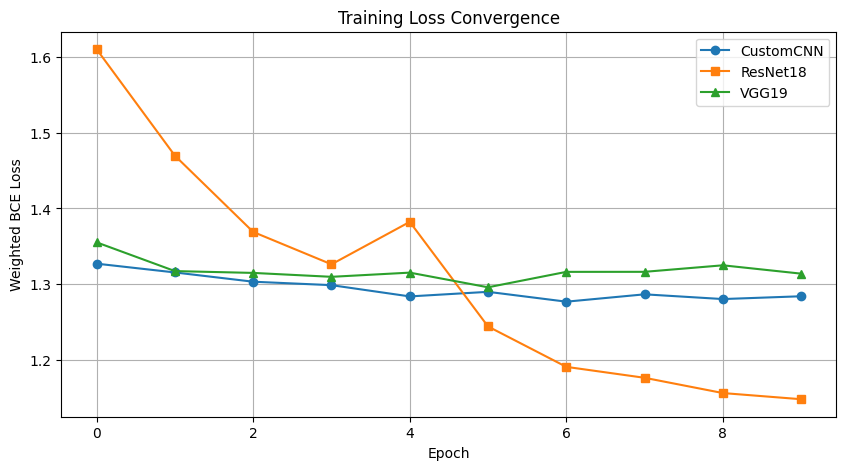

In [20]:
import torch
import matplotlib.pyplot as plt

# =====================================================
# LOAD TRAINING HISTORIES
# =====================================================

custom_history = torch.load(
    "customcnn_history.pth"
)

resnet_history = torch.load(
    "resnet18_history.pth"
)

vgg_history = torch.load(
    "vgg19_history.pth"
)

# =====================================================
# TRAINING LOSS CURVES
# =====================================================

plt.figure(figsize=(10, 5))

plt.plot(
    custom_history["train_loss"],
    marker="o",
    label="CustomCNN"
)

plt.plot(
    resnet_history["train_loss"],
    marker="s",
    label="ResNet18"
)

plt.plot(
    vgg_history["train_loss"],
    marker="^",
    label="VGG19"
)

plt.title(
    "Training Loss Convergence"
)

plt.xlabel("Epoch")

plt.ylabel("Weighted BCE Loss")

plt.grid(True)

plt.legend()

plt.show()

In [21]:
import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# GRAD-CAM FUNCTION
# =====================================================
def generate_gradcam(model, image, target_layer):

    model.eval()

    activations = []
    gradients = []

    # -------------------------
    # Hooks
    # -------------------------
    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    # -------------------------
    # Forward Pass
    # -------------------------
    image = image.to(device)

    output = model(
        image.unsqueeze(0)
    )

    probs = torch.sigmoid(output)

    pred_idx = torch.argmax(probs)

    # -------------------------
    # Backward Pass
    # -------------------------
    model.zero_grad()

    output[0, pred_idx].backward()

    # -------------------------
    # Remove Hooks
    # -------------------------
    forward_handle.remove()
    backward_handle.remove()

    # -------------------------
    # Extract Features
    # -------------------------
    grad = gradients[0].detach()

    act = activations[0].detach()

    weights = torch.mean(
        grad,
        dim=(2, 3),
        keepdim=True
    )

    cam = torch.sum(
        weights * act,
        dim=1
    )

    cam = F.relu(cam)

    cam = cam.squeeze()

    # -------------------------
    # Normalize
    # -------------------------
    cam = cam.cpu().numpy()

    cam = cam - cam.min()

    if cam.max() > 0:
        cam = cam / cam.max()

    # -------------------------
    # Resize Heatmap
    # -------------------------
    cam = cv2.resize(
        cam,
        (
            image.shape[2],
            image.shape[1]
        )
    )

    return cam, pred_idx.item()


# =====================================================
# VISUALIZATION FUNCTION
# =====================================================
def show_gradcam(
    model,
    dataset,
    target_layer,
    image_index=0
):

    image, label = dataset[image_index]

    heatmap, pred_idx = generate_gradcam(
        model,
        image,
        target_layer
    )

    img = image.cpu().permute(
        1,
        2,
        0
    ).numpy()

    img = (
        img - img.min()
    ) / (
        img.max() - img.min() + 1e-8
    )

    plt.figure(figsize=(12,5))

    # -------------------------
    # Original Image
    # -------------------------
    plt.subplot(1,2,1)

    plt.imshow(
        img.squeeze(),
        cmap='bone'
    )

    plt.title("Original X-Ray")

    plt.axis('off')

    # -------------------------
    # Grad-CAM Overlay
    # -------------------------
    plt.subplot(1,2,2)

    plt.imshow(
        img.squeeze(),
        cmap='bone'
    )

    plt.imshow(
        heatmap,
        cmap='jet',
        alpha=0.5
    )

    plt.title(
        f"Grad-CAM: {ALL_LABELS[pred_idx]}"
    )

    plt.axis('off')

    plt.tight_layout()

    plt.show()

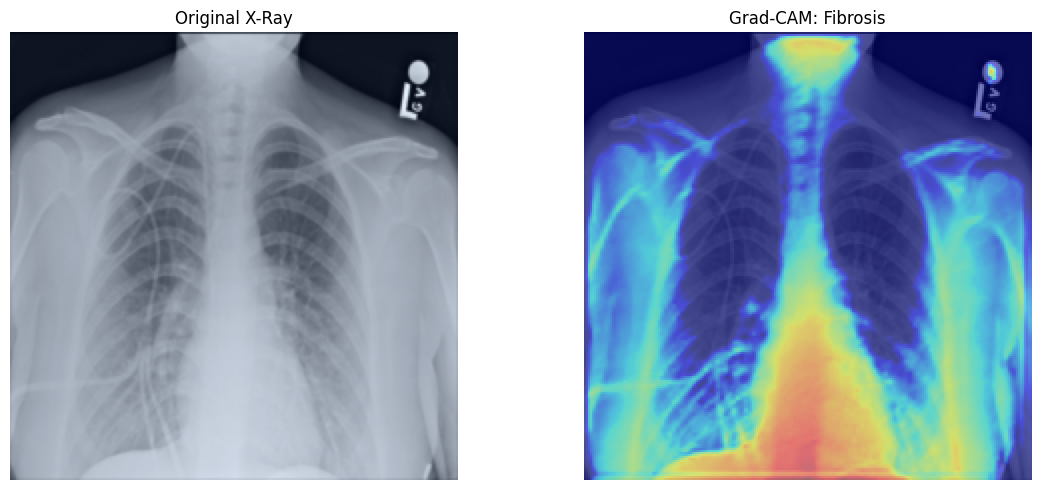

In [30]:
model = CustomCNN().to(device)

model.load_state_dict(
    torch.load("customcnn_best_model.pth")
)

model.eval()

target_layer = model.features[3]

show_gradcam(
    model=model,
    dataset=test_dataset,
    target_layer=target_layer,
    image_index=0
)

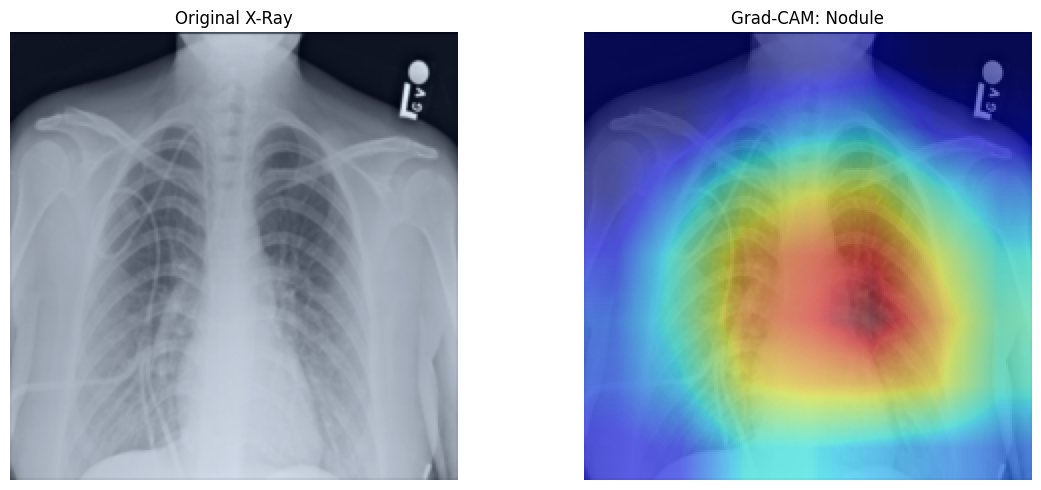

In [31]:
model = ResNet18Custom().to(device)

model.load_state_dict(
    torch.load("resnet18_best_model.pth")
)

model.eval()

target_layer = model.model.layer4[-1]

show_gradcam(
    model=model,
    dataset=test_dataset,
    target_layer=target_layer,
    image_index=0
)

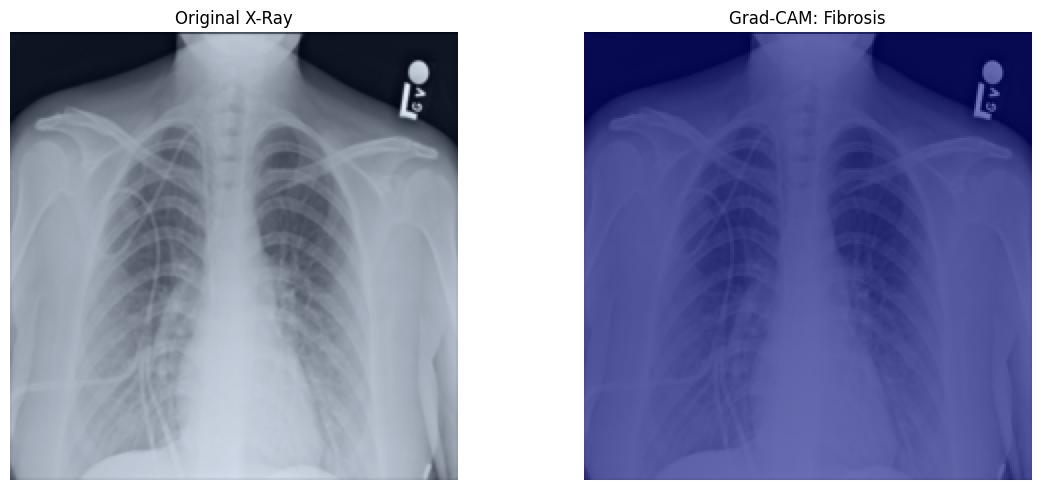

In [33]:
import torch.nn as nn

def replace_relu(module):

    for name, child in module.named_children():

        if isinstance(child, nn.ReLU):

            setattr(
                module,
                name,
                nn.ReLU(inplace=False)
            )

        else:

            replace_relu(child)


model = VGG19Custom().to(device)

replace_relu(model)

model.load_state_dict(
    torch.load("vgg19_best_model.pth")
)

model.eval()

target_layer = model.features[34]

show_gradcam(
    model=model,
    dataset=test_dataset,
    target_layer=target_layer,
    image_index=0
)

In [34]:
# =====================================================
# NIH CHEST X-RAY14
# RAG-GROUNDED CLINICAL INTERPRETATION LAYER
# =====================================================

medical_kb = {

    "Atelectasis": {
        "id": "KB-001",
        "text": "Atelectasis is a partial or complete collapse of lung tissue resulting in reduced air volume."
    },

    "Cardiomegaly": {
        "id": "KB-002",
        "text": "Cardiomegaly refers to enlargement of the heart and may be associated with heart failure or other cardiovascular diseases."
    },

    "Effusion": {
        "id": "KB-003",
        "text": "Pleural effusion is the accumulation of excess fluid within the pleural space surrounding the lungs."
    },

    "Infiltration": {
        "id": "KB-004",
        "text": "Infiltration refers to abnormal opacity within lung tissue that may represent infection, inflammation, or fluid accumulation."
    },

    "Mass": {
        "id": "KB-005",
        "text": "A pulmonary mass is a focal lung lesion that may require further clinical investigation."
    },

    "Nodule": {
        "id": "KB-006",
        "text": "A pulmonary nodule is a small rounded opacity within the lung and may be benign or malignant."
    },

    "Pneumonia": {
        "id": "KB-007",
        "text": "Pneumonia is an infection of the lung parenchyma causing inflammation and air-space opacification."
    },

    "Pneumothorax": {
        "id": "KB-008",
        "text": "Pneumothorax occurs when air enters the pleural space, causing partial or complete lung collapse."
    },

    "Consolidation": {
        "id": "KB-009",
        "text": "Consolidation refers to replacement of normal air within alveoli by fluid, pus, blood, or cells."
    },

    "Edema": {
        "id": "KB-010",
        "text": "Pulmonary edema is the accumulation of fluid within the lungs, often associated with heart failure."
    },

    "Emphysema": {
        "id": "KB-011",
        "text": "Emphysema is a chronic lung disease characterized by destruction of alveolar walls and air trapping."
    },

    "Fibrosis": {
        "id": "KB-012",
        "text": "Pulmonary fibrosis involves progressive scarring of lung tissue leading to reduced lung function."
    },

    "Pleural_Thickening": {
        "id": "KB-013",
        "text": "Pleural thickening refers to fibrosis or thickening of the pleural lining surrounding the lungs."
    },

    "Hernia": {
        "id": "KB-014",
        "text": "A hernia may appear on chest radiographs when abdominal contents protrude through the diaphragm."
    }
}


# =====================================================
# RETRIEVAL FUNCTION
# =====================================================

def retrieve_knowledge(label):

    if label in medical_kb:
        return medical_kb[label]

    return {
        "id": "KB-000",
        "text": "No supporting clinical knowledge available."
    }


# =====================================================
# CONFIDENCE CATEGORY
# =====================================================

def confidence_level(probability):

    if probability >= 0.80:
        return "High"

    elif probability >= 0.60:
        return "Moderate"

    else:
        return "Low"


# =====================================================
# GENERATE CLINICAL REPORT
# =====================================================

def generate_clinical_summary(
    predicted_labels,
    probabilities,
    heatmap_focus="thoracic region"
):

    report = []

    report.append("=" * 60)
    report.append("AI ASSISTIVE RADIOLOGY SUMMARY")
    report.append("=" * 60)
    report.append("")

    report.append("Predicted Findings:")
    report.append("")

    citations = []

    for label, prob in zip(predicted_labels, probabilities):

        knowledge = retrieve_knowledge(label)

        confidence = confidence_level(prob)

        report.append(
            f"- {label} | "
            f"Confidence: {confidence} ({prob:.2%})"
        )

        report.append(
            f"  Clinical Context: {knowledge['text']}"
        )

        citations.append(
            f"{knowledge['id']} ({label})"
        )

        report.append("")

    report.append(
        f"Grad-CAM Explanation: Model attention was concentrated in the {heatmap_focus}."
    )

    report.append("")

    report.append(
        "Interpretation:"
    )

    report.append(
        "The model identified imaging patterns that may be associated with the findings listed above. "
        "These predictions should be interpreted together with radiologist review, patient history, "
        "physical examination, and additional diagnostic testing."
    )

    report.append("")

    report.append("Model Limitations:")

    report.append(
        "- Predictions are generated by a deep learning model trained on ChestX-ray14."
    )

    report.append(
        "- Dataset labels may contain noise and uncertainty."
    )

    report.append(
        "- False positives and false negatives may occur."
    )

    report.append(
        "- Grad-CAM highlights regions influencing the model but does not establish causality."
    )

    report.append("")

    report.append("Disclaimer:")

    report.append(
        "This system is intended for research and assistive decision support only. "
        "It is NOT a medical diagnosis and must not replace professional clinical judgment."
    )

    report.append("")

    report.append("Citations:")

    for citation in citations:
        report.append(f"- {citation}")

    report.append("")
    report.append("=" * 60)

    return "\n".join(report)


# =====================================================
# EXAMPLE: CONNECT TO MODEL OUTPUT
# =====================================================

# Example predictions
predicted_labels = [
    "Effusion",
    "Cardiomegaly"
]

probabilities = [
    0.91,
    0.78
]

report = generate_clinical_summary(
    predicted_labels,
    probabilities,
    heatmap_focus="right lower lung field"
)

print(report)

AI ASSISTIVE RADIOLOGY SUMMARY

Predicted Findings:

- Effusion | Confidence: High (91.00%)
  Clinical Context: Pleural effusion is the accumulation of excess fluid within the pleural space surrounding the lungs.

- Cardiomegaly | Confidence: Moderate (78.00%)
  Clinical Context: Cardiomegaly refers to enlargement of the heart and may be associated with heart failure or other cardiovascular diseases.

Grad-CAM Explanation: Model attention was concentrated in the right lower lung field.

Interpretation:
The model identified imaging patterns that may be associated with the findings listed above. These predictions should be interpreted together with radiologist review, patient history, physical examination, and additional diagnostic testing.

Model Limitations:
- Predictions are generated by a deep learning model trained on ChestX-ray14.
- Dataset labels may contain noise and uncertainty.
- False positives and false negatives may occur.
- Grad-CAM highlights regions influencing the model 